# 231 — -1 / 0 / +1 Segmentation clustering

Loads blob objects from a 230 run (under the new manifest layout), paints -1/0/+1 maps, downsamples to 10%, clusters with KMeans (K-sweep) + Hierarchical.

Outputs land in `outputs/clustering/{kmeans,hierarchical}/minus101/runs/<timestamp>/` via `lf_cluster_run.fit_and_save`.
Each run writes: model.joblib, predictor.joblib, X_train.npy, labels.csv, metrics.json, manifest.json, plus standard figures and per-cluster mean -1/0/+1 thumbnails for the MOBA chips.


In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from functions import lf_blob_clustering_config as cfg
from functions.lf_clustering import s10_load_ersps
from functions.lf_minus101 import (
    s23_build_minus101_feature_matrix,
    q60_plot_minus101_overlays,
    q61_plot_minus101_prototype,
)
from functions.lf_blob_metrics import s22_build_blob_feature_matrix
from functions.lf_clustering_methods import (
    s53_compute_medoids,
    s54_compute_prototypes,
    q52_plot_prototype_grid,
)
from functions import lf_cluster_run as R

SCRIPT_NAME = '231_minus101_clustering.ipynb'


## Config

In [ ]:
# ── locate the upstream 230 blob run ─────────────────────────────
# 231 reuses 230's blob segmentation + score gating. We pick the latest blob run from the new layout.
# Set BLOB_RUN_ID to a specific timestamp string to pin a run; leave None for 'latest'.
BLOB_RUN_ID    = None
BLOB_METHOD    = 'kmeans'   # 'kmeans' or 'hierarchical' — either run dir works, both share blob_artifacts
CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)
BLOB_RUNS_DIR  = CLUSTERING_DIR / BLOB_METHOD / 'blob' / 'runs'
print('Looking for 230 blob runs under:', BLOB_RUNS_DIR)

# ── -101 downsampling ────────────────────────────────────────
SCALE = 0.10   # 10% of original — gives 13×30 = 390 features

# ── score gate (inherited from 230 run) ──────────────────────
SCORE_MIN = None   # set a float to gate per-blob; None keeps all

# ── clustering (orchestrator handles save layout) ────────────
KMEANS_K_RANGE = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
HC_METHOD      = 'average'
HC_METRIC      = 'euclidean'
HC_N_CLUSTERS  = 10
RANDOM_STATE   = cfg.RANDOM_STATE

print('SCALE:', SCALE, '  KMEANS_K_RANGE:', KMEANS_K_RANGE)


## 1 — Load 230 run (gating + blob objects)

In [ ]:
# sorted(RUNS_DIR_230.glob('*'))

In [ ]:
# Resolve the 230 blob run directory under the new manifest layout.
import joblib

if not BLOB_RUNS_DIR.exists():
    raise FileNotFoundError(
        f'No blob runs at {BLOB_RUNS_DIR}. Run 230_blob_clustering.ipynb first.'
    )

if BLOB_RUN_ID is None:
    candidates = sorted(p for p in BLOB_RUNS_DIR.iterdir() if p.is_dir())
    if not candidates:
        raise FileNotFoundError(f'No run subdirs in {BLOB_RUNS_DIR}.')
    run_dir_230 = candidates[-1]
    print('Using latest 230 blob run:', run_dir_230.name)
else:
    run_dir_230 = BLOB_RUNS_DIR / str(BLOB_RUN_ID)
    print('Using 230 blob run:', run_dir_230.name)

art_dir = run_dir_230 / 'blob_artifacts'
if not art_dir.exists():
    raise FileNotFoundError(
        f'No blob_artifacts/ in {run_dir_230}. The 230 notebook needs to be re-run after the refactor (it now writes blob_artifacts).'
    )

# Load gating config + small artifacts
with open(art_dir / 'gating_config.json') as f:
    gcfg = json.load(f)
keep_idx = np.load(art_dir / 'keep_idx.npy')
blobs_per_sample = joblib.load(art_dir / 'blobs_per_sample.joblib')
print(f'  keep_idx: {keep_idx.shape}  blobs_per_sample: {len(blobs_per_sample)} samples')

# Pull the gating config out so the rest of this notebook can use them.
INPUT_DIR  = Path(gcfg['input_dir'])
TASK       = gcfg['task']
CONDITIONS = tuple(gcfg['conditions'])
N_FREQ     = int(gcfg['n_freq'])
N_TIME     = int(gcfg['n_time'])
VALLEY_PARAMS = gcfg['valley_params']
print(f'  INPUT_DIR={INPUT_DIR}')
print(f'  TASK={TASK}  CONDITIONS={CONDITIONS}  N_FREQ={N_FREQ}  N_TIME={N_TIME}')

# Rebuild ersp_keep by replaying s10 + applying keep_idx (ERSPs aren't persisted in the run dir).
df_full, ersp_full = s10_load_ersps(
    input_dir=INPUT_DIR,
    task=TASK,
    allowed_conditions=CONDITIONS,
    n_freq=N_FREQ,
    n_time=N_TIME,
)
ersp_keep_list = [ersp_full[i] for i in keep_idx]
df_keep = df_full.iloc[keep_idx].reset_index(drop=True)
print(f'  df_keep: {df_keep.shape}  ersp_keep_list: {len(ersp_keep_list)}')


## 2 — Blob objects (loaded from 230 run, not re-segmented)


In [ ]:
# blobs_per_sample is now loaded directly from 230's blob_artifacts (see cell above). No need to re-segment.
print('blobs_per_sample ready — n samples:', len(blobs_per_sample))


## 3 — Build -101 feature matrix

In [6]:
X_101, ds_shape = s23_build_minus101_feature_matrix(
    ersp_list=ersp_keep_list,
    blobs_per_sample=blobs_per_sample,
    scale=SCALE,
    score_min=SCORE_MIN,
)
print('X_101:', X_101.shape, '  ds_shape:', ds_shape)

[s23_build_minus101_feature_matrix]
  Original map : 129×300 = 38700 bins
  Downsampled  : 13×30 = 390 features  (scale=10%)
  X_101.shape  : (263, 390)
  Samples with any blob activity: 263/263
X_101: (263, 390)   ds_shape: (13, 30)


## 4 — QC: painted -101 maps

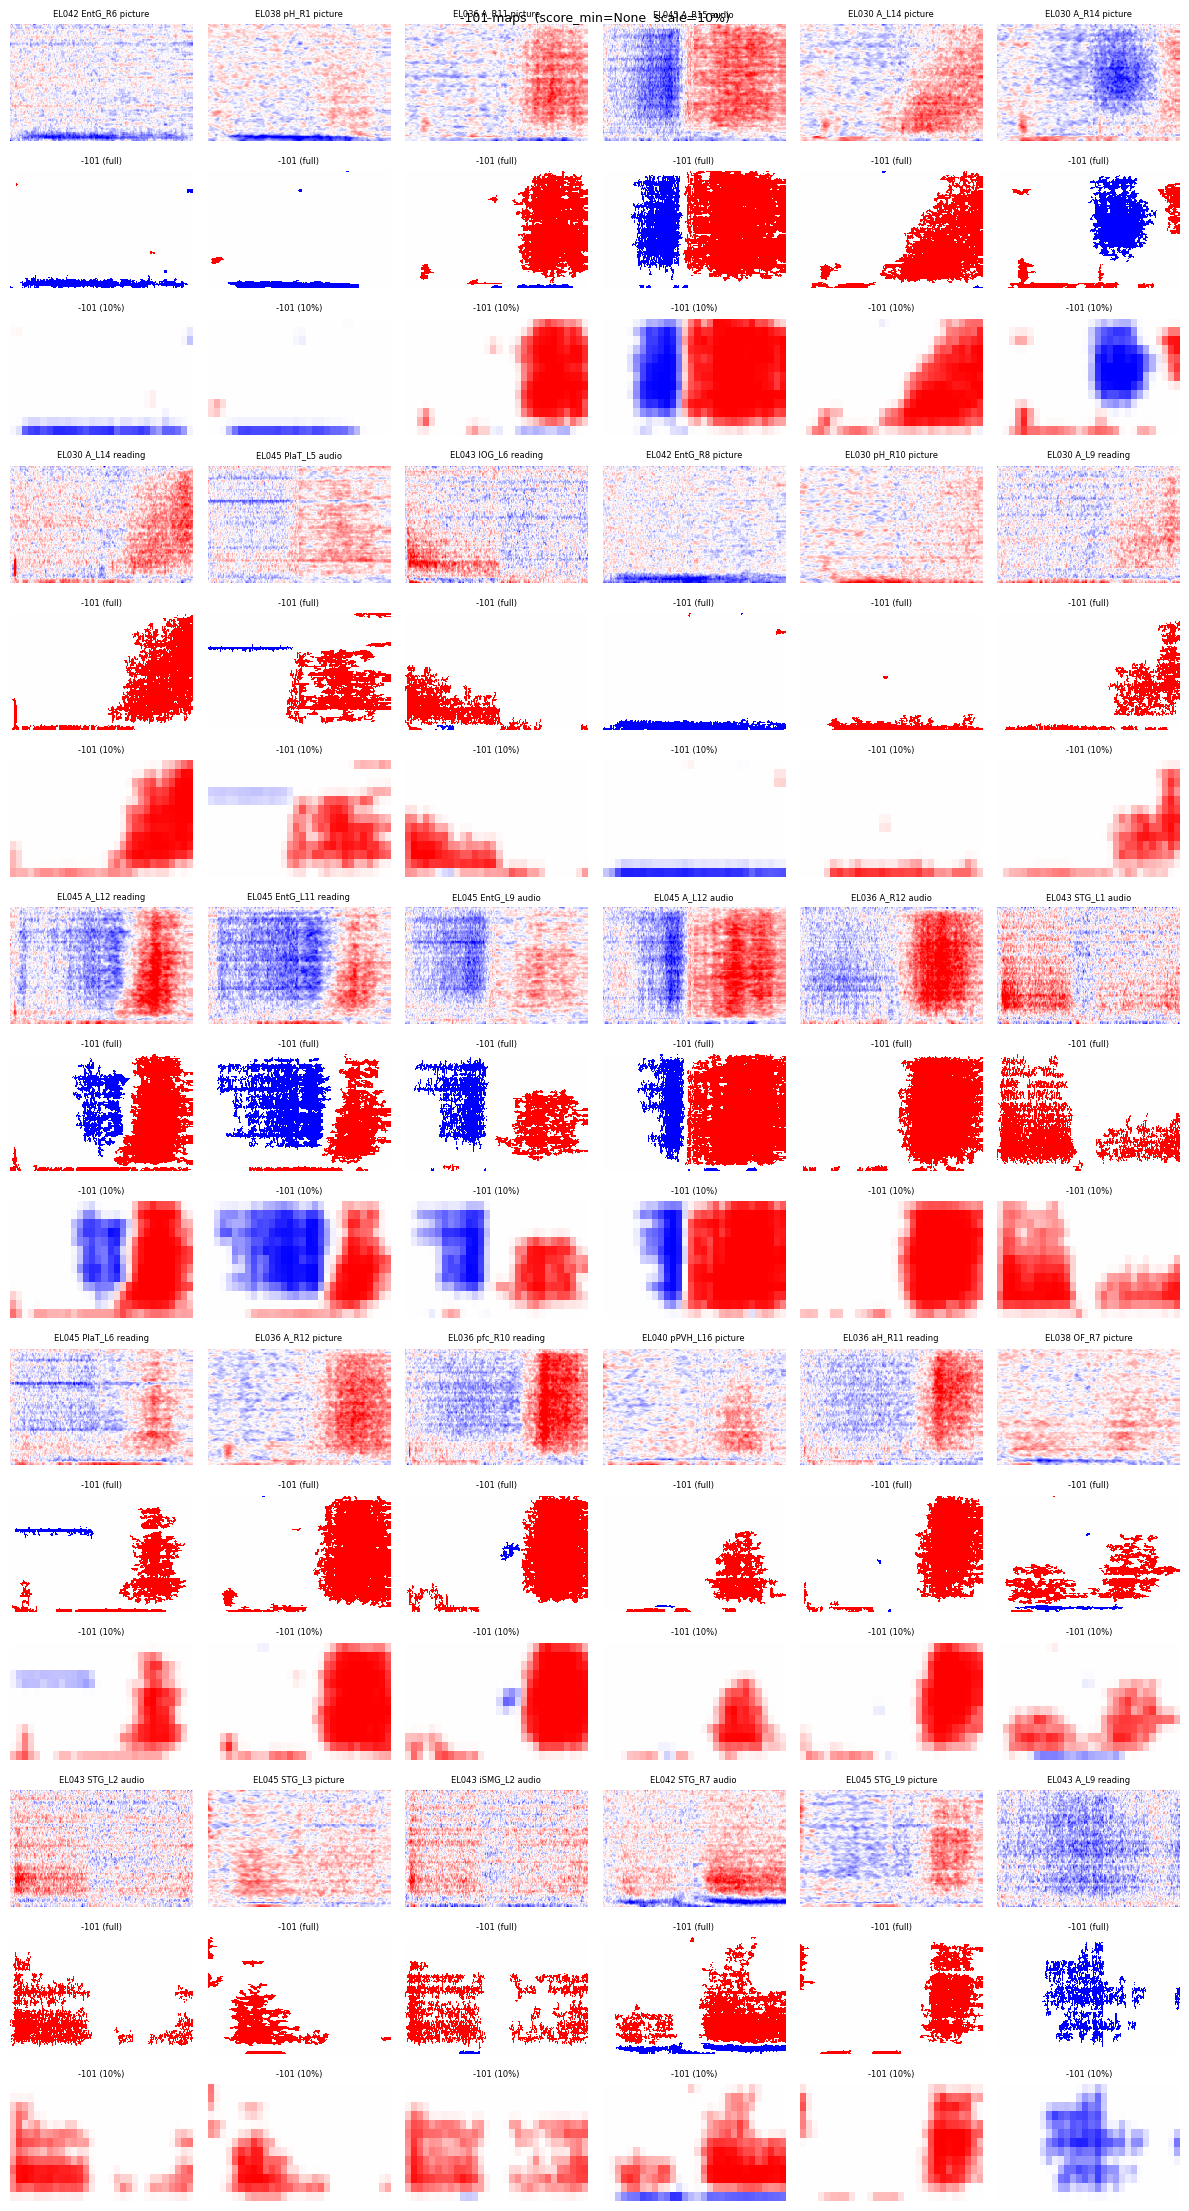

In [7]:
# Sample 30 random indices for visual inspection
rng = np.random.default_rng(42)
qc_idx = rng.choice(len(ersp_keep_list), size=min(30, len(ersp_keep_list)), replace=False).tolist()

q60_plot_minus101_overlays(
    indices=qc_idx,
    ersp_list=ersp_keep_list,
    blobs_per_sample=blobs_per_sample,
    df_meta=df_keep,
    scale=SCALE,
    score_min=SCORE_MIN,
)

# Clustering

Two methods on the same `X_101` (downsampled -1 / 0 / +1 painted maps, flattened): K-Means (K-sweep) and Hierarchical.
Each `fit_and_save` call writes a self-contained run directory and updates `outputs/clustering/index.json`.


In [ ]:
# KMeans K-sweep on minus101 features.
manifest_km = R.fit_and_save(
    X_101,
    df_keep=df_keep,
    method='kmeans',
    feature_set='minus101',
    params={'k_range': KMEANS_K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    method_label='K-Means',
    feature_set_label='\u22121 / 0 / +1 Segmentation',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f'Best K (KMeans/minus101, by silhouette): {BEST_K}')


In [ ]:
# Hierarchical on minus101 features.
manifest_hc = R.fit_and_save(
    X_101,
    df_keep=df_keep,
    method='hierarchical',
    feature_set='minus101',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'n_clusters': HC_N_CLUSTERS},
    method_label='Hierarchical',
    feature_set_label='\u22121 / 0 / +1 Segmentation',
    notebook=SCRIPT_NAME,
)


## Per-cluster centroid PNGs (for the MOBA cluster chips)

Walks `index.json`, for every `feature_set == 'minus101'` run, computes the mean -1/0/+1 map
per cluster (using `X_101` reshaped back to `ds_shape`) and writes
`<run_dir>/cluster_centroids/cluster_<NN>.png`. The MOBA chip thumbnails update automatically.


In [ ]:
# BACKFILL_CENTROIDS — per-cluster mean -1/0/+1 thumbnails for the MOBA chips (minus101 feature_set).
import json

INDEX_PATH = CLUSTERING_DIR / 'index.json'

def _save_per_cluster_centroid_pngs_minus101(manifest, X_local, ds_shape_local, *, vlim=1.0):
    if manifest['feature_set'] != 'minus101':
        return 0
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] / 'runs' / manifest['run_id']
    df = pd.read_csv(run_dir / 'labels.csv')
    cluster_col = f"cluster_{manifest['method']}_{manifest['feature_set']}"
    if cluster_col not in df.columns:
        cands = [c for c in df.columns if c.startswith('cluster_')]
        if not cands: return 0
        cluster_col = cands[0]
    labels = df[cluster_col].to_numpy()
    if len(labels) != X_local.shape[0]:
        print(f"  [skip] {manifest['run_id']}: labels ({len(labels)}) vs X_101 ({X_local.shape[0]}) mismatch — re-run cells 5–10 in this notebook with the same gating as the run")
        return 0
    out_dir = run_dir / 'cluster_centroids'
    out_dir.mkdir(parents=True, exist_ok=True)
    uniq = sorted(int(c) for c in np.unique(labels))
    for c in uniq:
        idx = np.where(labels == c)[0]
        mean_map = X_local[idx].mean(axis=0).reshape(ds_shape_local)  # (ds_freq, ds_time) ≈ (13, 30)
        fig, ax = plt.subplots(figsize=(2, 1.5))
        ax.imshow(mean_map, aspect='auto', origin='lower',
                  cmap='bwr', vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        out_path = out_dir / f'cluster_{int(c):02d}.png'
        fig.savefig(out_path, dpi=80, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    return len(uniq)

if not INDEX_PATH.exists():
    print(f'No {INDEX_PATH} yet — run the fit_and_save cells above first.')
else:
    with open(INDEX_PATH) as f:
        idx_data = json.load(f)
    runs = [r for r in idx_data.get('runs', []) if r['feature_set'] == 'minus101']
    print(f'Backfilling per-cluster centroid PNGs for {len(runs)} minus101 runs...')
    for run in runs:
        manifest_path = CLUSTERING_DIR / run['path'] / 'manifest.json'
        if not manifest_path.exists():
            print(f"  [skip] {run['path']}: missing manifest.json"); continue
        with open(manifest_path) as f:
            manifest = json.load(f)
        n = _save_per_cluster_centroid_pngs_minus101(manifest, X_101, ds_shape)
        if n:
            print(f"  [{manifest['method']}/{manifest['feature_set']}] {manifest['run_id']}  ->  {n} cluster PNGs")
    print('\nDone. Commit and push:')
    print('  git add 02_FBM_Clustering/outputs/clustering')
    print('  git commit -m "Per-cluster centroid PNGs for MOBA chips (minus101)"')
    print('  git push')
